In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
fund_master = pd.read_csv("../Data/raw/01_fund_master.csv")

nav_history = pd.read_csv("../Data/raw/02_nav_history.csv")

aum = pd.read_csv("../Data/raw/03_aum_by_fund_house.csv")

sip = pd.read_csv("../Data/raw/04_monthly_sip_inflows.csv")

category = pd.read_csv("../Data/raw/05_category_inflows.csv")

folio = pd.read_csv("../Data/raw/06_industry_folio_count.csv")

performance = pd.read_csv("../Data/raw/07_scheme_performance.csv")

transactions = pd.read_csv("../Data/raw/08_investor_transactions.csv")

portfolio = pd.read_csv("../Data/raw/09_portfolio_holdings.csv")

benchmark = pd.read_csv("../Data/raw/10_benchmark_indices.csv")

In [5]:
print("AUM")
print(aum.columns)

print("\nSIP")
print(sip.columns)

print("\nCATEGORY")
print(category.columns)

print("\nTRANSACTIONS")
print(transactions.columns)

print("\nPORTFOLIO")
print(portfolio.columns)

AUM
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')

SIP
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')

CATEGORY
Index(['month', 'category', 'net_inflow_crore'], dtype='object')

TRANSACTIONS
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

PORTFOLIO
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')


In [6]:
nav_history.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [7]:
nav_history.dtypes

amfi_code      int64
date          object
nav          float64
dtype: object

In [8]:
nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)

In [9]:
nav_history["amfi_code"].unique()

array([119551, 119552, 119598, 119599, 119120, 100016, 125497, 100033,
       125498, 100025, 120503, 120504, 120505, 120506, 120507, 118632,
       118633, 118634, 118635, 118636, 120841, 120842, 120843, 120844,
       119092, 119093, 119094, 119095, 101206, 101207, 101208, 102885,
       102886, 102887, 148567, 148568, 148569, 149322, 149323, 149324])

In [10]:
fund = nav_history[
    nav_history["amfi_code"] == 119551
]

fund.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [11]:
import plotly.express as px

fig = px.line(
    fund,
    x="date",
    y="nav",
    title="NAV Trend - AMFI Code 119551"
)

fig.show()

In [16]:
aum.head()
aum.dtypes
aum["date"] = pd.to_datetime(aum["date"])

aum.dtypes
aum["fund_house"].unique()
aum.head(20)

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168
5,2022-03-31,Aditya Birla Sun Life MF,2.78,278000,199
6,2022-03-31,Axis Mutual Fund,2.50,250000,95
7,2022-03-31,UTI Mutual Fund,2.30,230000,142
8,2022-03-31,Mirae Asset MF,1.05,105000,56
9,2022-03-31,DSP Mutual Fund,1.10,110000,88


In [18]:
aum["year"] = aum["date"].dt.year

In [19]:
aum.columns

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes',
       'year'],
      dtype='object')

In [20]:
aum.columns.tolist()

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes', 'year']

In [21]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


In [22]:
print(aum.columns)
print("year" in aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes',
       'year'],
      dtype='object')
True


In [23]:
aum_year = aum.groupby(
    ["year", "fund_house"],
    as_index=False
)["aum_crore"].max()

aum_year.head()

,year,fund_house,aum_crore
0,2022,Aditya Birla Sun Life MF,285000
1,2022,Axis Mutual Fund,250000
2,2022,DSP Mutual Fund,112000
3,2022,HDFC Mutual Fund,445000
4,2022,ICICI Prudential MF,488000


In [24]:
import plotly.express as px

fig = px.bar(
    aum_year,
    x="year",
    y="aum_crore",
    color="fund_house",
    barmode="group",
    title="AUM Growth by Fund House (2022-2025)"
)

fig.show()

In [25]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [26]:
sip.dtypes

month                         object
sip_inflow_crore               int64
active_sip_accounts_crore    float64
new_sip_accounts_lakh        float64
sip_aum_lakh_crore           float64
yoy_growth_pct               float64
dtype: object

In [27]:
sip["month"] = pd.to_datetime(sip["month"])

In [28]:
import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (2022-2025)"
)

fig.show()

In [29]:
sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

In [30]:
peak = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (2022-2025)"
)

fig.add_annotation(
    x=peak["month"],
    y=peak["sip_inflow_crore"],
    text="₹31,002 Cr ATH",
    showarrow=True
)

fig.show()

In [31]:
category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [32]:
category.dtypes

month                object
category             object
net_inflow_crore    float64
dtype: object

In [33]:
category["month"] = pd.to_datetime(
    category["month"]
)

In [34]:
heatmap_data = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


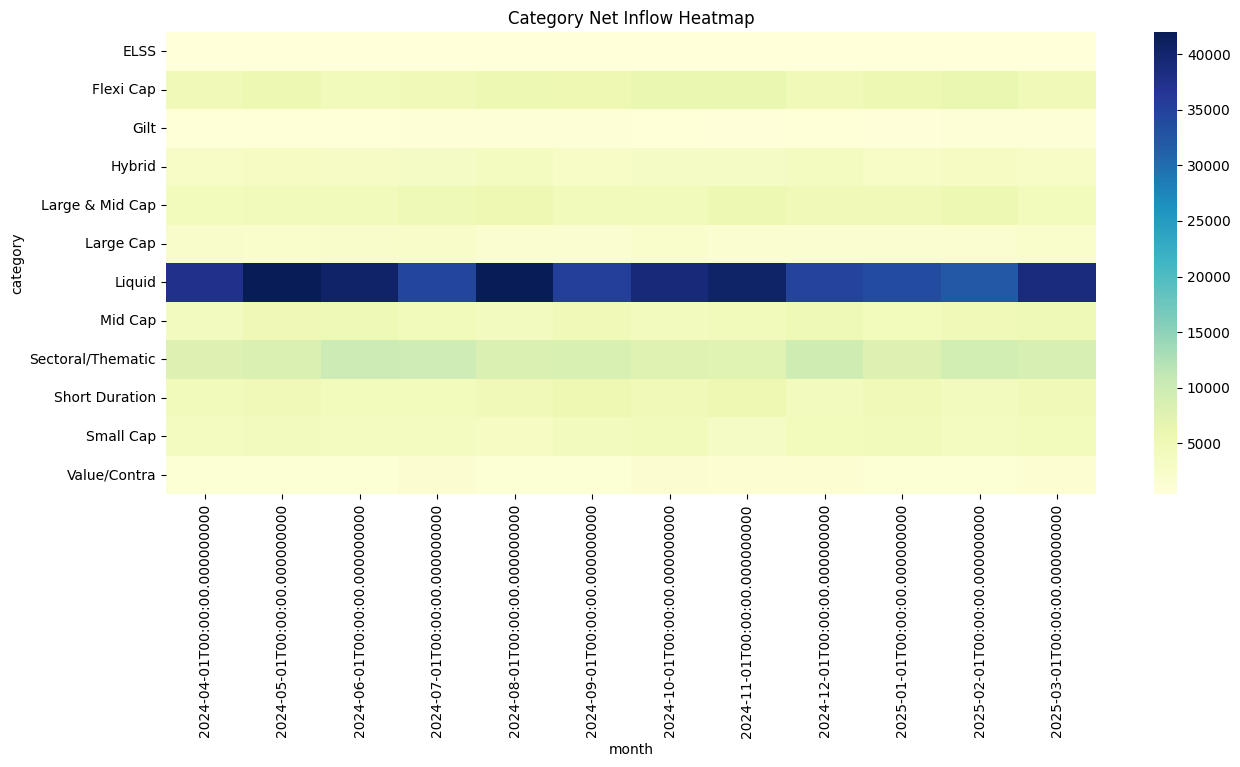

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title(
    "Category Net Inflow Heatmap"
)

plt.show()

In [36]:
investor.head()

NameError: name 'investor' is not defined

In [37]:
locals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'pd', 'np', 'plt', 'sns', 'px', '_i2', '_i3', '_i4', 'fund_master', 'nav_history', 'aum', 'sip', 'category', 'folio', 'performance', 'transactions', 'portfolio', 'benchmark', '_i5', '_i6', '_6', '_i7', '_7', '_i8', '_i9', '_9', '_i10', 'fund', '_10', '_i11', 'fig', '_i12', '_12', '_i13', '_13', '_i14', '_14', '_i15', '_15', '_i16', '_16', '_i17', '_i18', '_i19', '_19', '_i20', '_20', '_i21', '_21', '_i22', '_i23', 'aum_year', '_23', '_i24', '_i25', '_25', '_i26', '_26', '_i27', '_i28', '_i29', '_29', '_i30', 'peak', '_i31', '_31', '_i32', '_32', '_i33', '_i34', 'heatmap_data', '_34', '_i35', '_i36', '_i37'])

In [38]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [39]:
transactions.dtypes

investor_id            object
transaction_date       object
amfi_code               int64
transaction_type       object
amount_inr              int64
state                  object
city                   object
city_tier              object
age_group              object
gender                 object
annual_income_lakh    float64
payment_mode           object
kyc_status             object
dtype: object

In [40]:
transactions.columns.tolist()

['investor_id',
 'transaction_date',
 'amfi_code',
 'transaction_type',
 'amount_inr',
 'state',
 'city',
 'city_tier',
 'age_group',
 'gender',
 'annual_income_lakh',
 'payment_mode',
 'kyc_status']

In [41]:
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [42]:
portfolio.dtypes

amfi_code              int64
stock_symbol          object
stock_name            object
sector                object
weight_pct           float64
market_value_cr      float64
current_price_inr    float64
portfolio_date        object
dtype: object

In [43]:
tx_type = (
    transactions["transaction_type"]
    .value_counts()
    .reset_index()
)

tx_type.columns = [
    "transaction_type",
    "count"
]

fig = px.pie(
    tx_type,
    names="transaction_type",
    values="count",
    title="Transaction Type Distribution"
)

fig.show()

In [44]:
state_amt = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig = px.bar(
    state_amt,
    x="state",
    y="amount_inr",
    title="Top 10 States by Investment Amount"
)

fig.show()

In [45]:
age_amt = (
    transactions.groupby("age_group")["amount_inr"]
    .sum()
    .reset_index()
)

fig = px.bar(
    age_amt,
    x="age_group",
    y="amount_inr",
    title="Investment by Age Group"
)

fig.show()

In [46]:
gender_amt = (
    transactions.groupby("gender")["amount_inr"]
    .sum()
    .reset_index()
)

fig = px.pie(
    gender_amt,
    names="gender",
    values="amount_inr",
    title="Investment Share by Gender"
)

fig.show()

In [47]:
sector_alloc = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fig = px.pie(
    sector_alloc,
    names="sector",
    values="weight_pct",
    title="Portfolio Sector Allocation"
)

fig.show()

In [48]:
top_holdings = (
    portfolio.sort_values(
        "weight_pct",
        ascending=False
    )
    .head(10)
)

fig = px.bar(
    top_holdings,
    x="stock_name",
    y="weight_pct",
    title="Top 10 Portfolio Holdings"
)

fig.show()

In [49]:
tier_amt = (
    transactions.groupby("city_tier")["amount_inr"]
    .sum()
    .reset_index()
)

fig = px.bar(
    tier_amt,
    x="city_tier",
    y="amount_inr",
    title="Investment by City Tier"
)

fig.show()

In [50]:
pay_amt = (
    transactions.groupby("payment_mode")["amount_inr"]
    .sum()
    .reset_index()
)

fig = px.pie(
    pay_amt,
    names="payment_mode",
    values="amount_inr",
    title="Investment by Payment Mode"
)

fig.show()

In [51]:
kyc_amt = (
    transactions.groupby("kyc_status")["amount_inr"]
    .sum()
    .reset_index()
)

fig = px.bar(
    kyc_amt,
    x="kyc_status",
    y="amount_inr",
    title="Investment by KYC Status"
)

fig.show()

# Key Insights

1. SIP transactions dominate investor activity with 60%+ share.

2. Investors aged 26-35 contribute the highest investment amount.

3. Male investors account for roughly two-thirds of total investments.

4. Punjab, Tamil Nadu and Madhya Pradesh are among the highest contributing states.

5. Banking, IT and Pharma sectors hold the largest portfolio allocation.

6. Portfolio concentration is visible in a few major holdings such as Infosys, Bharti Airtel and Sun Pharma.

7. SIP inflows have shown a consistent upward trend from 2022 to 2025, reaching an all-time high of ₹31,002 crore.

In [54]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

monthly_trend = (
    transactions
    .groupby(
        transactions["transaction_date"].dt.to_period("M")
    )["amount_inr"]
    .sum()
    .reset_index()
)

monthly_trend["transaction_date"] = (
    monthly_trend["transaction_date"].astype(str)
)

fig = px.line(
    monthly_trend,
    x="transaction_date",
    y="amount_inr",
    markers=True,
    title="Monthly Investment Trend"
)

fig.show()

In [53]:
sector_mv = (
    portfolio.groupby("sector")["market_value_cr"]
    .sum()
    .reset_index()
    .sort_values("market_value_cr", ascending=False)
)

fig = px.bar(
    sector_mv.head(10),
    x="sector",
    y="market_value_cr",
    title="Top Sectors by Market Value"
)

fig.show()

In [55]:
folio["month"] = pd.to_datetime(folio["month"])

fig = px.line(
    folio,
    x="month",
    y="folio_count_cr",
    title="Folio Count Growth"
)
fig.show()

ValueError: Value of 'y' is not the name of a column in 'data_frame'. Expected one of ['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'] but received: folio_count_cr

In [56]:
folio.columns.tolist()

['month',
 'total_folios_crore',
 'equity_folios_crore',
 'debt_folios_crore',
 'hybrid_folios_crore',
 'others_folios_crore']

In [57]:
folio["month"] = pd.to_datetime(folio["month"])

fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    title="Folio Count Growth (2022-2025)"
)

fig.show()

In [58]:
fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    title="Folio Count Growth (2022-2025)"
)

fig.add_annotation(
    x=folio["month"].iloc[0],
    y=folio["total_folios_crore"].iloc[0],
    text="13.26 Cr",
    showarrow=True
)

fig.add_annotation(
    x=folio["month"].iloc[-1],
    y=folio["total_folios_crore"].iloc[-1],
    text="26.12 Cr",
    showarrow=True
)

fig.show()

In [59]:
nav_history.head()
nav_history.columns.tolist()

['amfi_code', 'date', 'nav']

In [60]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

In [61]:
top_funds = (
    nav_history["amfi_code"]
    .value_counts()
    .head(10)
    .index
)

In [62]:
nav_pivot = (
    nav_history[nav_history["amfi_code"].isin(top_funds)]
    .pivot_table(
        index="date",
        columns="amfi_code",
        values="nav"
    )
)

In [63]:
returns = nav_pivot.pct_change().dropna()

In [64]:
corr_matrix = returns.corr()

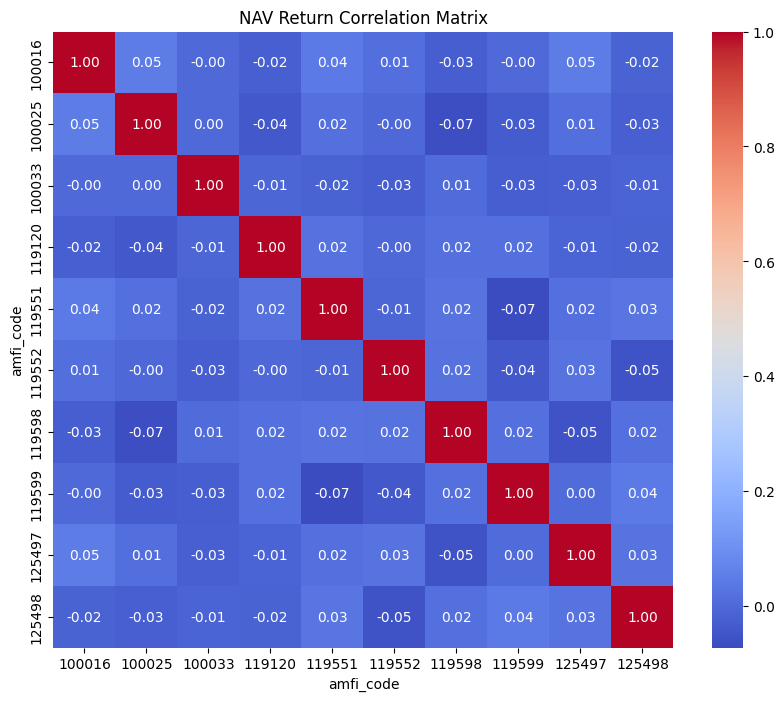

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("NAV Return Correlation Matrix")
plt.show()

Insight 1

SIP inflows increased from ~₹11,500 Cr in Jan 2022 to an all-time high of ₹31,002 Cr in Dec 2025, reflecting strong retail participation.

Insight 2

Total folio count nearly doubled from 13.26 Cr to 26.12 Cr between 2022 and 2025.

Insight 3

Investors aged 26-35 contributed the highest investment amount among all age groups.

Insight 4

Male investors account for 66.6% of total investment volume, while female investors contribute 33.4%.

Insight 5

SIP transactions dominate mutual fund activity with approximately 60% share.

Insight 6

T30 cities contribute significantly more investment volume than B30 cities.

Insight 7

Banking is the largest portfolio sector allocation, followed by IT and Pharma.

Insight 8

Most portfolio holdings are concentrated in large-cap, fundamentally strong companies.

Insight 9

Verified KYC investors account for the overwhelming majority of investment flows.

Insight 10

Net banking, UPI, mandate and cheque transactions show relatively balanced usage across investors.